In [25]:
#@title Import libraries
import numpy as np
import pandas as pd
import SystemDynamics as sd
import math
import DynamicSystemSolver as dss
import matplotlib.pyplot as plt
import importlib
importlib.reload(dss)

<module 'DynamicSystemSolver' from 'e:\\PhD_Research\\My_research\\self_interactive_assist_as_needed\\Code\\SelfInteractiveAAN_SIAAN\\DynamicSystemSolver.py'>

In [26]:
#@title Functions
# Iterative learning method
def TrajectoryGenerationMTC(t0, tf, num, q0, qf, alpha, threshold = 0.01, gamma = 0.4, ips = 0.01):
    dim = len(q0)
    E = [1000] * 3 * dim
    Xf = [0] * 3 * dim
    Xf[:dim] = qf
    itr = 0
    while 1:
        S = np.zeros((3*dim, 3*dim))
        sol = dss.solveSystemDynamics(t0,tf,num,q0,qf,alpha)
        XPhi = sol.y 
        realXf = XPhi[:3*dim,-1]
        E = realXf - Xf
        print(f"Iteration: {itr}:: ||E||: {np.linalg.norm(E)}  alpha: {alpha}")
        if np.linalg.norm(E) < threshold:
            break
        else:
            itr = itr + 1
            for j in range(0,3*dim):
                ej = np.array([1 if k == j else 0 for k in range(3*dim)])
                solIps = dss.solveSystemDynamics(t0, tf, num, q0, qf, alpha + ips * ej)
                XPhiIps = solIps.y 
                realXfIps = XPhiIps[:3*dim,-1]
                EIps = realXfIps - Xf
                S[:,j] = (EIps-E)/ips
            alpha = alpha - gamma * np.linalg.inv(S) @ E
    return sol 


In [27]:
#@title Set up parameters
q0 = [math.radians(45),math.radians(90)]
qf = [math.radians(0),math.radians(80)]
num = 15
t0 = 0
tf = 0.8
dim = len(q0)
threshold = 0.01
gamma = 0.4
alpha = [0]*3*dim
# alpha = [-0.05761063, -0.14958106,  0.07689672, -0.00758357,  0.69947065, -0.55737955]
ips = 0.01


In [28]:
sol = dss.solveSystemDynamics(t0,tf,num,q0,qf,alpha)

In [ ]:
#@title Trajectory generation
sol = TrajectoryGenerationMTC(t0, tf, num, q0, qf, alpha, threshold, gamma, ips)

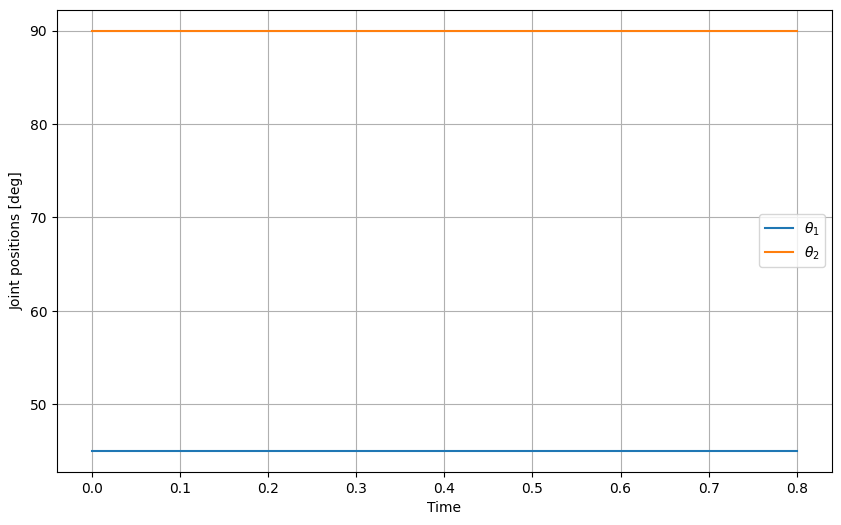

C:\Users\THINKPAD\AppData\Local\Temp\ipykernel_8168\3763526959.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


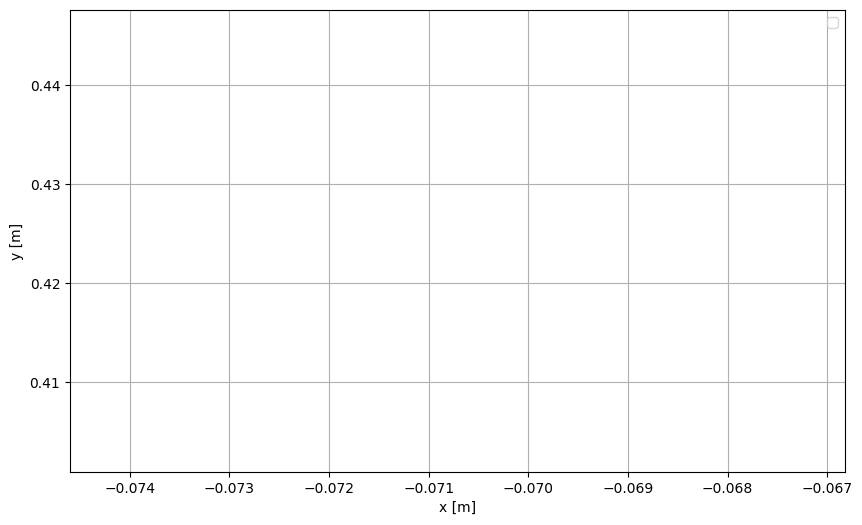

In [29]:
#@title Results visualization
# sol contains X and phi
# what we want is pos, vel, and torque
XPhi = sol.y
pos = XPhi[:dim,:]
vel = XPhi[dim:2*dim,:]
torque = XPhi[2*dim:,:]
time = sol.t
plt.figure(figsize=(10, 6))
plt.plot(time, 180/math.pi*pos[0,:], label=r'$\theta_1$')
plt.plot(time, 180/math.pi*pos[1,:], label=r'$\theta_2$')
plt.xlabel('Time')
plt.ylabel('Joint positions [deg]')
plt.legend()
plt.grid(True)
plt.show()
# In task space
plt.figure(figsize=(10, 6))
posX = sd.Lh[0]*np.cos(pos[0,:]) + sd.Lh[1]*np.cos(pos[0,:]+pos[1,:])
posY = sd.Lh[0]*np.sin(pos[0,:]) + sd.Lh[1]*np.sin(pos[0,:]+pos[1,:])
plt.plot(posX, posY)
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#@title Save the data
data = {
    'pos': pos,
    'vel': vel,
    'torque': torque,
    'time': time
}
df = pd.DataFrame(data)

# Save to CSV
df.to_csv('trajectoryresults.csv', index=False)